In [5]:
import gpflow as gpf
import tensorflow as tf
tf.random.set_seed(42)
import numpy as np
np.random.seed(42)
from gpflow.models.training_mixins import InternalDataTrainingLossMixin
import matplotlib.pyplot as plt
from gpflow.inducing_variables import InducingPoints
from gpflow.models.util import inducingpoint_wrapper
from robust_svgp import LMCInducingPointsBase

In [6]:


class SparseCMOGP_QR(gpf.models.GPModel, InternalDataTrainingLossMixin):
    def __init__(
        self,
        data,
        kernel,
        likelihood,
        mean_function=None,
        num_latent_gps=1,
        inducing_variable=[],
        exact_target=False,
        jitter=1e-6,
        conditioning_index=1
    ):
        super().__init__(kernel, likelihood, mean_function, num_latent_gps=1)
        self.data = data
        self.kernel = kernel
        self.likelihood = likelihood
        self.inducing_variable = inducingpoint_wrapper(inducing_variable) #InducingPoints(inducing_variable[:, 0].reshape(-1, 1))
        self.mean_function = gpf.mean_functions.Zero()
        self.conditioning_indices = [0]
        self.opt_logs = []
        self.exact_target = exact_target
        self.jitter = tf.cast(jitter, tf.float64)
        self.conditioning_index = conditioning_index

    def conditional_likelihood(
            self, *args, decompose_likelihood=False, **kwargs
        ) -> tf.Tensor:
            # Rebuild: look at all unique indices.
            # Then, figure out what set to condition on
            # Then, gather all conditioning variables as source, rest as target.

            Xs, Ys = self.data
            # Kall = self.kernel(Xs)
            Xind = self.inducing_variable.Z
            # tf.print(Kall.shape)

            # Determine what is source and what is target (currently use only one target var)
            As = Ys[:, 1] != self.conditioning_index
            Bs = Ys[:, 1] == self.conditioning_index

            Ax, Ay = tf.reshape(Xs[:, 0][As], (-1, 1)), tf.reshape(Ys[:, 0][As], (-1, 1))
            Bx, By = tf.reshape(Xs[:, 0][Bs], (-1, 1)), tf.reshape(Ys[:, 0][Bs], (-1, 1))


            # Exact matrices
            Kbb = self.kernel(Xs[Bs])
            Kaa = self.kernel(Xs[As])

            # Approximate matrices
            # inducing_variable = tf.concat(
            #     (self.inducing_variable.Z, self.inducing_indices), -1
            # )
            inducing_variable = self.inducing_variable.Z
            Kmm = self.kernel(
                inducing_variable
            )  + tf.eye(inducing_variable.shape[0], dtype=tf.float64) * self.jitter
            Kma = self.kernel(inducing_variable, Xs[As])
            Kmb = self.kernel(inducing_variable, Xs[Bs])
            Kam = tf.transpose(Kma)
            Qmb, Rmb = tf.linalg.qr(tf.transpose(Kmb), full_matrices=False)
            Qma, Rma = tf.linalg.qr(tf.transpose(Kma), full_matrices=False)

            # Steps to avoid explicit inverse of Kmm
            L_Kmm = tf.linalg.cholesky(Kmm)  # [1]
            Lmm_inv_kma = tf.linalg.triangular_solve(
                L_Kmm, Kma
            )  # L_Kmm x = Kma, x = L_Kmm^-1 Kma
            Lmm_inv_kmb = tf.linalg.triangular_solve(
                L_Kmm, Kmb
            )  # L_Kmm x = Kmb, x = L_Kmm^-1 Kmb

            Qbb = tf.matmul(Lmm_inv_kmb, Lmm_inv_kmb, transpose_a=True)
            Qaa = tf.matmul(Lmm_inv_kma, Lmm_inv_kma, transpose_a=True)

            # Full approximations of the exact matrices
            diag_Qtt = tf.linalg.diag_part(Qbb)
            diag_Ktt = tf.linalg.diag_part(Kbb)
            sigma_t = tf.squeeze(self.likelihood.target.variance_at(Bx))
            D_t = (diag_Ktt - diag_Qtt) + sigma_t

            diag_Qss = tf.linalg.diag_part(Qaa)
            diag_Kss = tf.linalg.diag_part(Kaa)
            sigma_s = tf.squeeze(self.likelihood.source.variance_at(Ax))
            D_s = (diag_Kss - diag_Qss) + sigma_s


            W = Kmm + tf.transpose(Rma) @ tf.transpose(Qma) @ tf.linalg.diag(1.0 / D_s) @ Qma @ Rma # [3]
            Lw = tf.linalg.cholesky(W)  # [3]

            u = tf.linalg.diag(1.0 / D_s) @ Ay
            mu_t = Qmb @ Rmb @ tf.linalg.cholesky_solve(
                Lw, tf.transpose(Rma) @ tf.transpose(Qma) @ u
            )  # Kbm W^1 Kma Ds^-1 Ay

            WRmb = tf.linalg.triangular_solve(Lw, tf.transpose(Rmb))
            BmWmt = Qmb @ tf.matmul(WRmb, WRmb, transpose_a=True) @ tf.transpose(Qmb)

            if not self.exact_target:
                C_t = BmWmt + tf.linalg.diag(D_t)
            else:  # Approximate everything.
                C_t = Kbb - Qbb + BmWmt + tf.linalg.diag(D_t)

            delta = By - mu_t
            L_t = tf.linalg.cholesky(C_t)
            alpha_t = tf.linalg.triangular_solve(L_t, delta)
            n_target = tf.cast(tf.shape(Bx)[0], Bx.dtype)
            logdet_t = 2.0 * tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L_t)))
            quad = tf.matmul(alpha_t, alpha_t, transpose_a=True)
            lml = -0.5 * (
                logdet_t
                + quad
                + n_target * tf.cast(tf.math.log(2 * tf.constant(np.pi)), Bx.dtype)
            )

            if not decompose_likelihood:
                return tf.squeeze(lml)
            else:
                return (
                    logdet_t.numpy().flatten(),
                    quad.numpy().flatten(),
                    (n_source * tf.cast(tf.math.log(2 * tf.constant(np.pi)), Ax.dtype))
                    .numpy()
                    .flatten(),
                )


    def maximum_log_likelihood_objective(self):
        return self.conditional_likelihood()

    def predict_f(self, Xnew, full_cov: bool = False, full_output_cov: bool = False):
        r"""
        Allegedly, the GP prediction stays the same.
        This method computes predictions at X \in R^{N \x D} input points

        .. math::
            p(F* | Y)

        where F* are points on the GP at new data points, Y are noisy observations at training data
        points.
        """

        Xs, Ys = self.data
        Xind = self.inducing_variable.Z

        err = (Ys - self.mean_function(Xs))[:, 0][:, None]

        As = Ys[:, 1] != self.conditioning_index
        Bs = Ys[:, 1] == self.conditioning_index

        err_As = err[As]
        err_Bs = err[Bs]
        err_reorder = tf.concat((err_As, err_Bs), axis=0)

        knn = self.kernel(
            Xnew, full_cov=full_cov
        )  # + tf.squeeze(self.likelihood.target.variance_at(Xnew))

        Ax, Ay = tf.reshape(Xs[:, 0][As], (-1, 1)), tf.reshape(Ys[:, 0][As], (-1, 1))
        Bx, By = tf.reshape(Xs[:, 0][Bs], (-1, 1)), tf.reshape(Ys[:, 0][Bs], (-1, 1))


        indices_A = tf.reshape(tf.where(As), [-1])
        indices_B = tf.reshape(tf.where(Bs), [-1])

        # Reorder indices to account for A/B reordering
        X_ordered = tf.gather(Xs, tf.concat([indices_A, indices_B], axis=0))

        # Compute exact kernel parts
        Kbb = self.kernel(Xs[Bs])
        Kaa = self.kernel(Xs[As])

        # Compute inducing points x rest data
        inducing_variable = self.inducing_variable.Z 
        Kma = self.kernel(inducing_variable, Xs[As])
        Kmb = self.kernel(inducing_variable, Xs[Bs])
        Kam = tf.transpose(Kma)
        Kmm = (
            self.kernel(inducing_variable)
            + np.eye(len(Xind.numpy()), dtype=np.float64) * self.jitter
        )
        L_Kmm = tf.linalg.cholesky(Kmm)
        Lmm_inv_kma = tf.linalg.triangular_solve(L_Kmm, Kma)  # Ax = b, x= A-1b
        Lmm_inv_kmb = tf.linalg.triangular_solve(L_Kmm, Kmb)

        # Use above to compute approximations and diagonal
        Qaa = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kma)
        Qab = tf.matmul(tf.transpose(Lmm_inv_kma), Lmm_inv_kmb)
        Qba = tf.transpose(Qab)
        Qbb = tf.matmul(tf.transpose(Lmm_inv_kmb), Lmm_inv_kmb)
        
        Qmb, Rmb = tf.linalg.qr(tf.transpose(Kmb), full_matrices=False)
        Qma, Rma = tf.linalg.qr(tf.transpose(Kma), full_matrices=False)

        # Full approximations of the exact matrices, target
        diag_Qtt = tf.linalg.diag_part(Qbb)
        diag_Ktt = tf.linalg.diag_part(Kbb)
        sigma_t = tf.squeeze(self.likelihood.target.variance_at(Bx))
        D_b = (diag_Ktt - diag_Qtt) + sigma_t

        # Full approximations of the exact matrices, source
        diag_Qss = tf.linalg.diag_part(Qaa)
        diag_Kss = tf.linalg.diag_part(Kaa)
        sigma_s = tf.squeeze(self.likelihood.source.variance_at(Ax))
        D_a = (diag_Kss - diag_Qss) + sigma_s

        W = Kmm + Kma @ tf.linalg.diag(1.0 / D_a) @ Kam  # [3]
        Lw = tf.linalg.cholesky(W)

        BmWmt = tf.transpose(Kmb) @ tf.linalg.cholesky_solve(
            Lw, Kmb
        )  # LwLw^T x = Kmb, x = W^1 Kmb

        # Blockwise inversion of K_fic
        D_a_inv = tf.linalg.diag(1.0 / D_a)
        M = tf.linalg.cholesky(Kmm + tf.transpose(Rma) @ tf.transpose(Qma) @ D_a_inv @ Qma @ Rma)
        half = tf.linalg.triangular_solve(M, tf.transpose(Rma) @ tf.transpose(Qma) @ D_a_inv)  # m by m, m by a
        Qaa_inv = D_a_inv - tf.linalg.matmul(half, half, transpose_a=True)

        C_b = BmWmt + tf.linalg.diag(D_b)
        D_b_inv = tf.linalg.diag(1.0 / D_b)
        Qbb_inv = D_b_inv - D_b_inv @ Qmb @ Rmb @ tf.linalg.inv(W + tf.transpose(Rmb) @ tf.transpose(Qmb) @ D_b_inv @ Qmb @ Rmb) @ tf.transpose(Rmb) @ tf.transpose(Qmb) @ D_b_inv
        # L_Qbb = tf.linalg.cholesky(C_b)  # order N_t
        # Qbb_inv = tf.linalg.cholesky_solve(
        #     L_Qbb, np.eye(len(Bx))
        # )  # LL^T x = I, x = (LL^T)^1

        A = Qaa_inv + Qaa_inv @ Qab @ Qbb_inv @ Qba @ Qaa_inv
        B = -Qaa_inv @ Qab @ Qbb_inv
        C = -Qbb_inv @ Qba @ Qaa_inv
        D = Qbb_inv

        K_fic_inv = tf.concat((tf.concat((A, B), 1), tf.concat((C, D), 1)), 0)

        # Construct Kmn
        Knm = (
            self.kernel(X_ordered, inducing_variable)
            @ tf.linalg.inv(Kmm)
            @ self.kernel(inducing_variable, Xnew)
        )
        cond = tf.transpose(Knm) @ K_fic_inv @ Knm
        f_mean_zero = tf.transpose(Knm) @ K_fic_inv @ err_reorder
        f_var = tf.expand_dims(tf.linalg.diag_part(knn - cond), 1)

        # tf.print("fm0", f_mean_zero.shape)
        f_mean = f_mean_zero + self.mean_function(Xnew[:, 0][:, None])
        return f_mean, f_var 


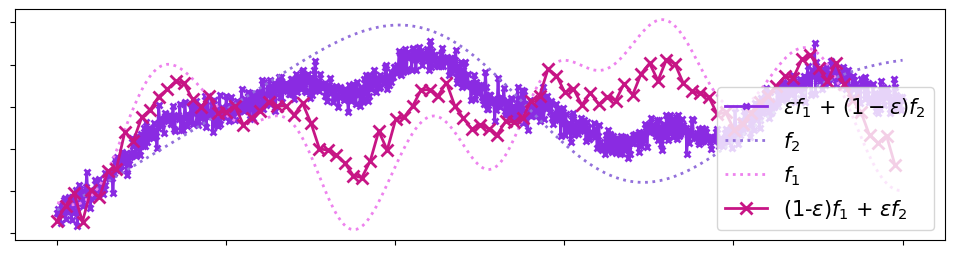

In [7]:
Xs = np.linspace(0, 50, 1000).reshape(-1, 1)
Xt = np.linspace(0, 50, 1000).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(Xs.flatten()), gpf.kernels.RBF(lengthscales=10, variance=2)(Xs))
f2 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.RBF(lengthscales=3)(Xt))

prop = 0.7
ys = (prop * f1 + (1-prop) * f2 + np.random.normal(0, 0.1, len(Xs))).reshape(-1, 1)
yt = ((1-prop)* f1 + prop * f2 + np.random.normal(0, 0.1, len(Xt))).reshape(-1, 1)
yt = [y for i, y in enumerate(yt) if i % 10 == 0]
Xt = [x for i, x in enumerate(Xt) if i % 10 == 0]
yt_train = yt[:int(len(Xt)*0.75)]
Xt_train = Xt[:int(len(Xt)*0.75)]
yt_test = yt[int(len(Xt)*0.75):]
Xt_test = Xt[int(len(Xt)*0.75):]

plt.figure(figsize=(12, 3))
plt.tick_params(
    axis='both',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    labelleft=False,
    labelbottom=False
) # labels along the bottom edge are off
plt.plot(Xs, ys, color="blueviolet", marker="x", ms=5, lw=2, mew=2, label="$\epsilon$$f_1$ + $(1-\epsilon)$$f_2$")
plt.plot(Xs, f1, color="mediumpurple", linestyle=":", lw=2, label="$f_2$")
plt.plot(Xs, f2, color="violet", linestyle=":", lw=2, label="$f_1$")
plt.plot(Xt, yt, color="mediumvioletred", marker="x", ms=8, mew=2, lw=2,label="(1-$\epsilon$)$f_1$ + $\epsilon$$f_2$")
plt.legend(fontsize=15)
plt.show()

X = np.vstack((np.hstack((Xs, np.zeros_like(Xs))), np.hstack((Xt_train, np.ones_like(Xt_train)))))
y = np.vstack((np.hstack((ys, np.zeros_like(ys))), np.hstack((yt_train, np.ones_like(yt_train)))))


╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[1].W               

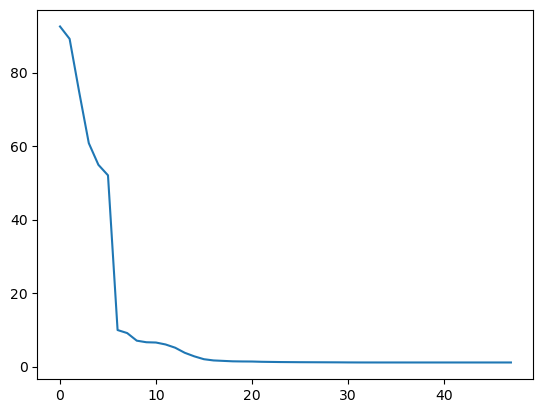

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.17723674511266885     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 4.2107                  │
├────────────────────────────────────────────────┼───────────┼──────────────────┼───────

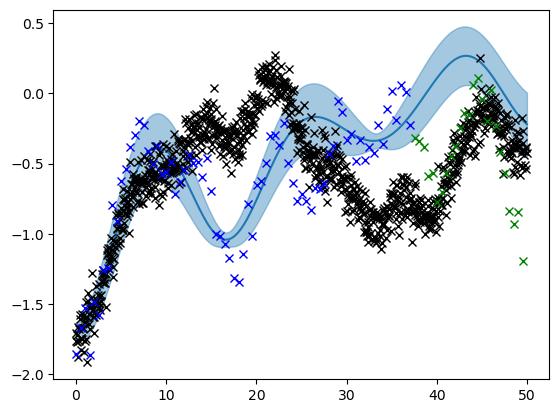

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:42:27.862595: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:42:28.056288: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

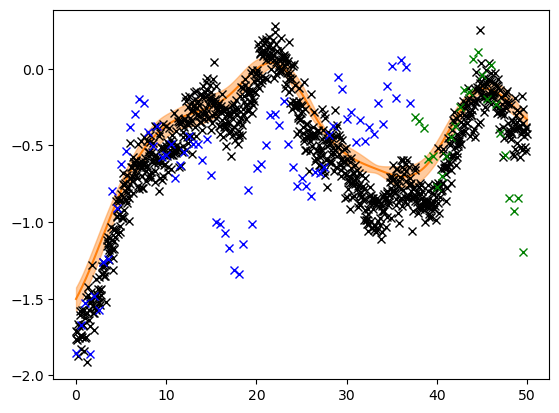

IVS 10 CMOGP 0.32585617414849893 SVGP 0.11101326068792929
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─

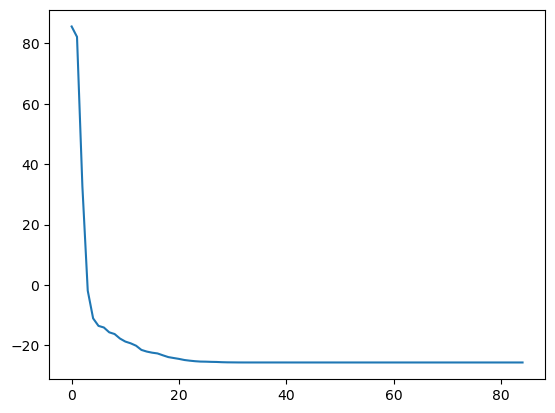

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0020110411340417997           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 2.88916                         │
├───────────────────────────────────────

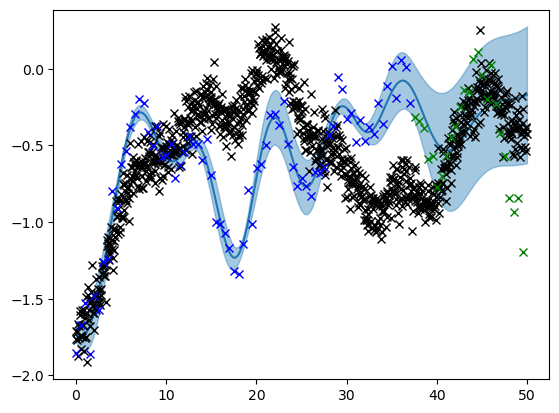

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:42:48.271722: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:42:48.350016: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

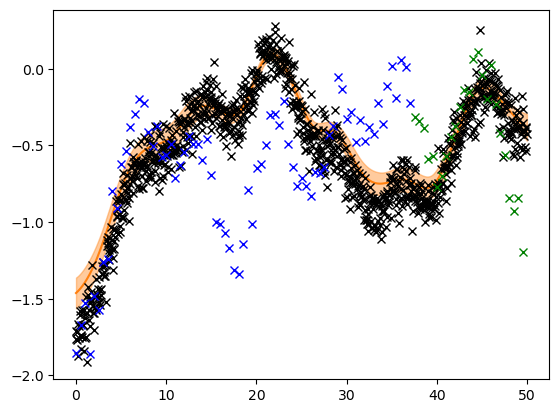

IVS 20 CMOGP 0.13873095753525796 SVGP 0.10570395476850064
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─

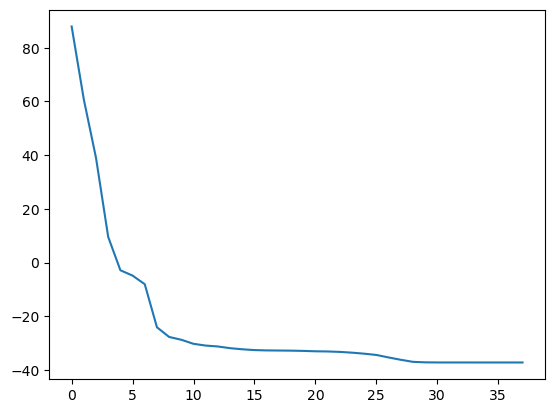

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0406283288282973              │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 5.26862                         │
├───────────────────────────────────────

/tmp/ipykernel_2344/3357134900.py:49: RuntimeWarning: invalid value encountered in sqrt
  (fmean - 1 * np.sqrt(fvar))[:, 0],
/tmp/ipykernel_2344/3357134900.py:50: RuntimeWarning: invalid value encountered in sqrt
  (fmean + 1 * np.sqrt(fvar))[:, 0],


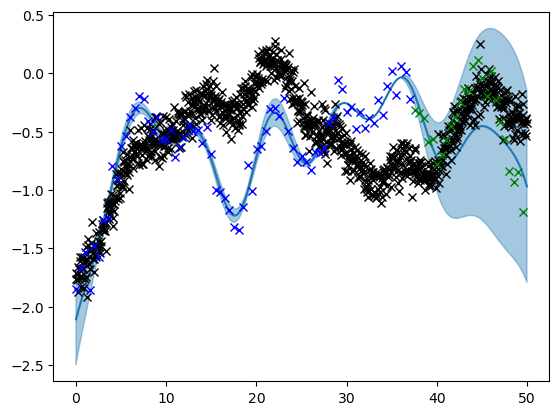

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:43:08.036944: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:43:08.162086: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

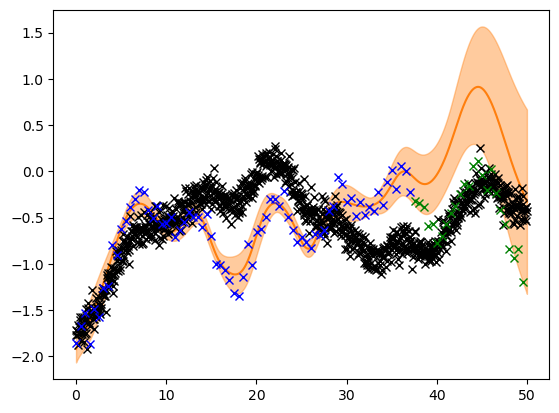

IVS 30 CMOGP 0.09069282644617413 SVGP 0.6205694023883275
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──

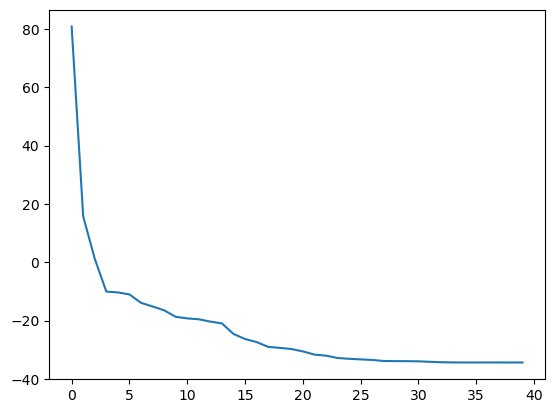

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                         │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.009395964677396862          │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.87872                       │
├────────────────────────────────────────────────┼──

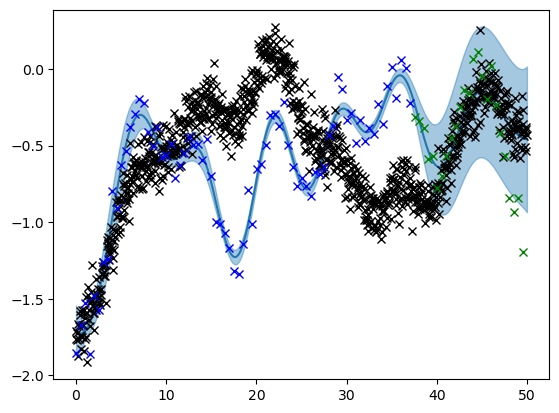

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:43:43.221182: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:43:43.467513: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

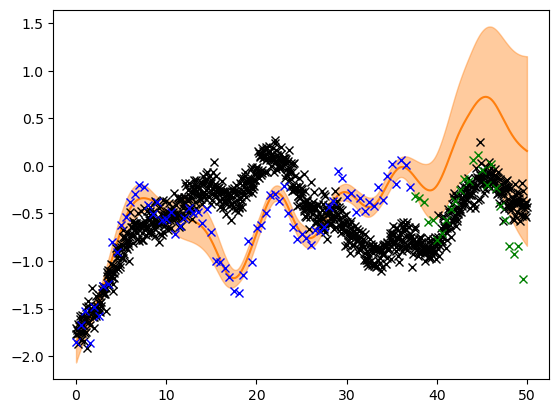

IVS 40 CMOGP 0.06403327062614472 SVGP 0.5811303751854274
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──

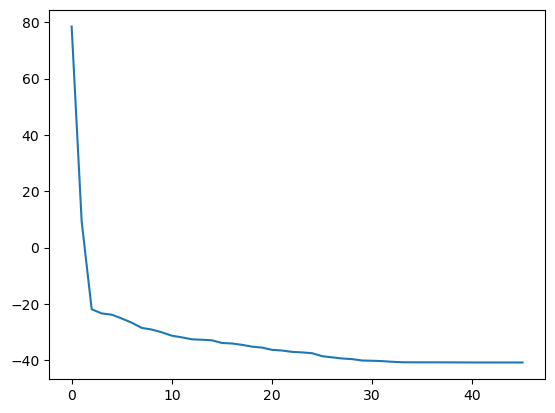

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.00745768876097434             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.16713                         │
├───────────────────────────────────────

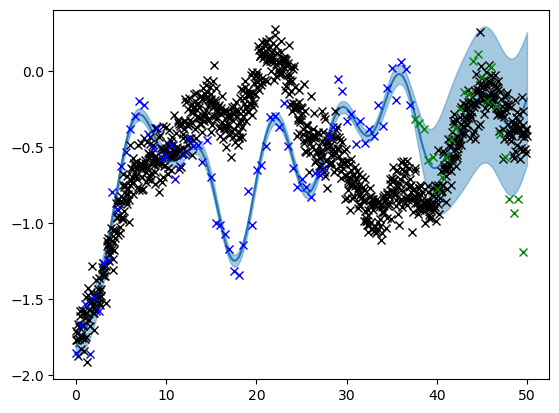

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:44:28.607941: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:44:29.058829: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

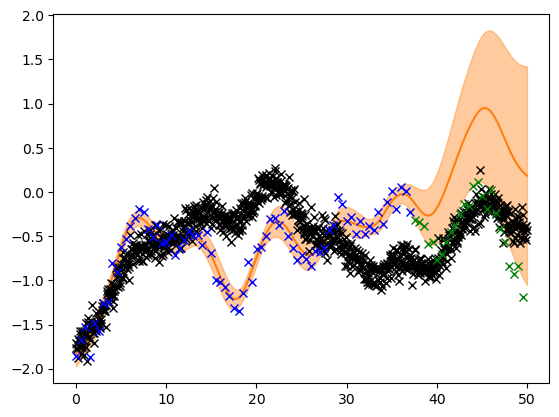

IVS 50 CMOGP 0.08533135893306408 SVGP 0.7564514020697745
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──

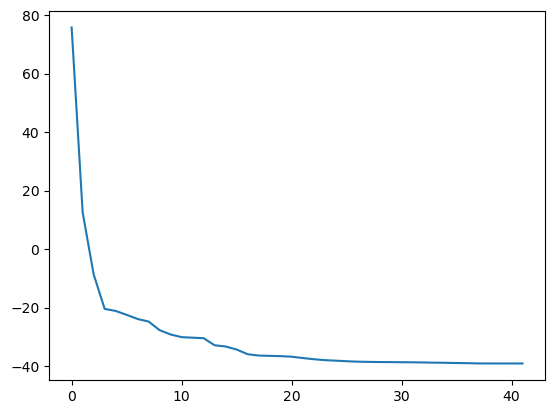

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.00448281761793541             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.62071                         │
├───────────────────────────────────────

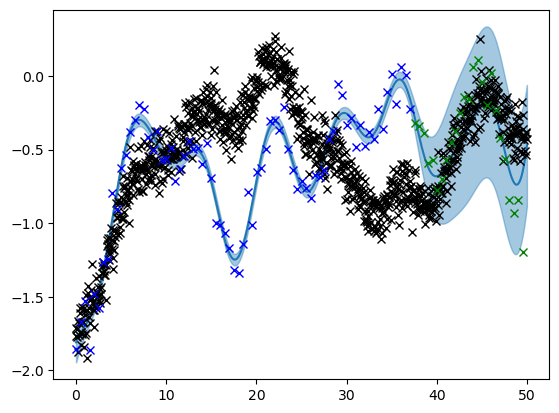

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:45:41.717963: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:45:41.815125: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

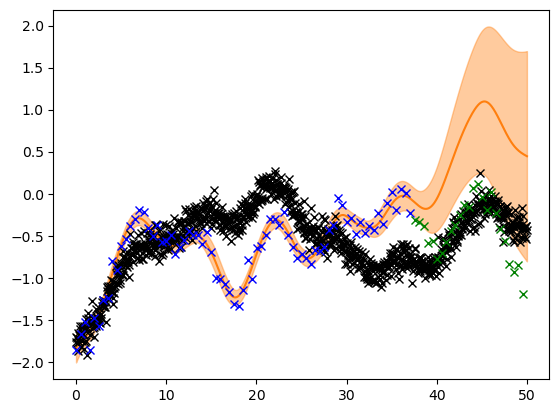

IVS 60 CMOGP 0.0381984145308463 SVGP 1.0319648256774412
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───

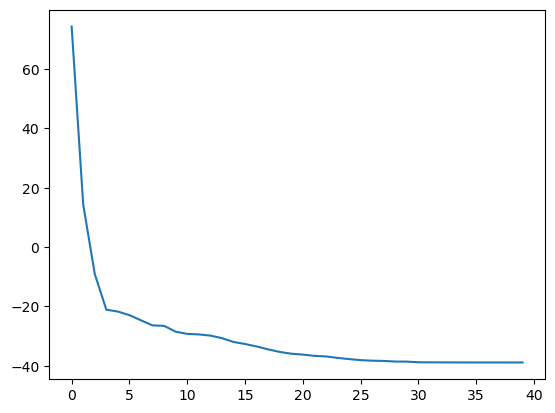

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0031376995558699224           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.09104                         │
├───────────────────────────────────────

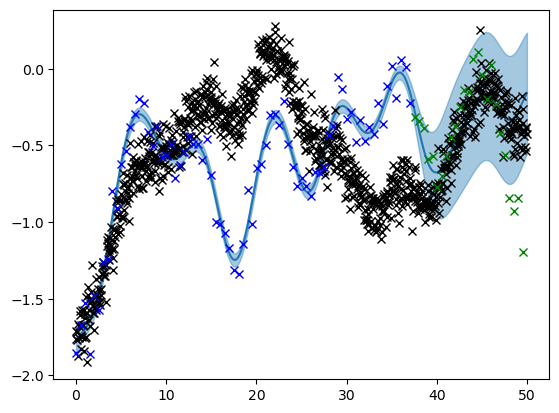

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:46:46.562279: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:46:46.658067: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

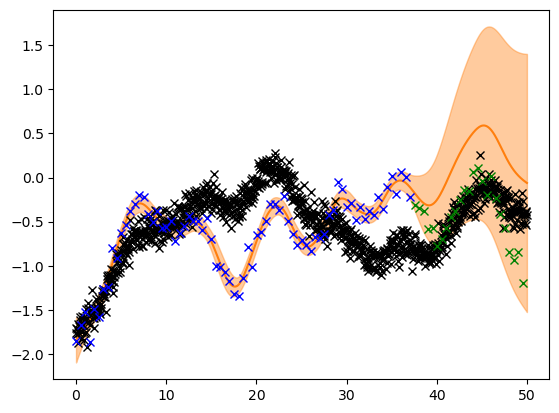

IVS 70 CMOGP 0.09805726159725307 SVGP 0.3995140634025708
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──

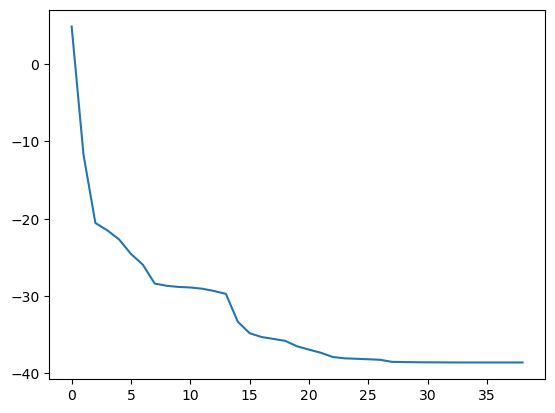

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.01653658123257772             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.27728                         │
├───────────────────────────────────────

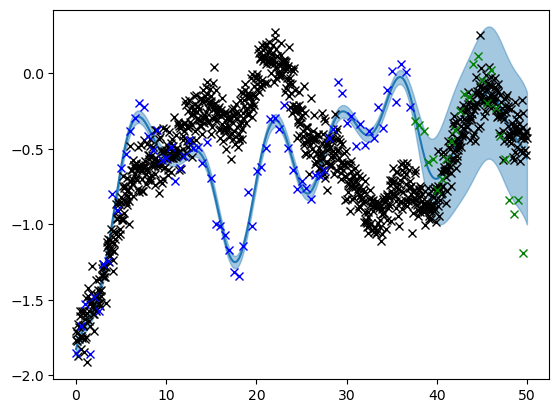

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:47:33.382396: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:47:33.445116: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

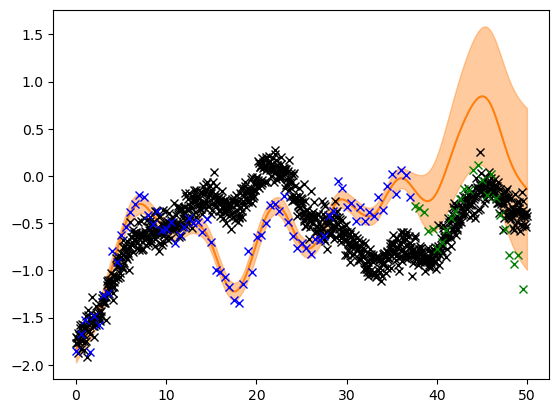

IVS 80 CMOGP 0.06865950401590955 SVGP 0.5478720999085426
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──

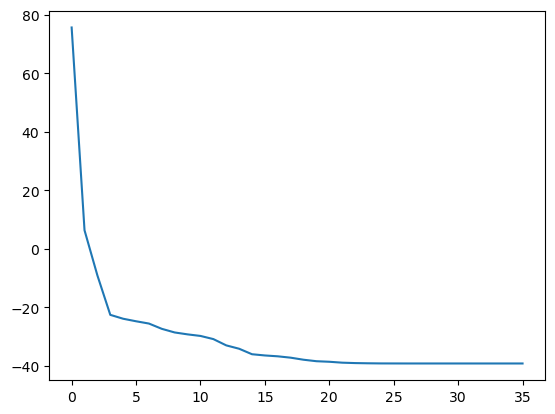

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.02730974641818221     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 3.13005                 │
├────────────────────────────────────────────────┼───────────┼──────────────────┼───────

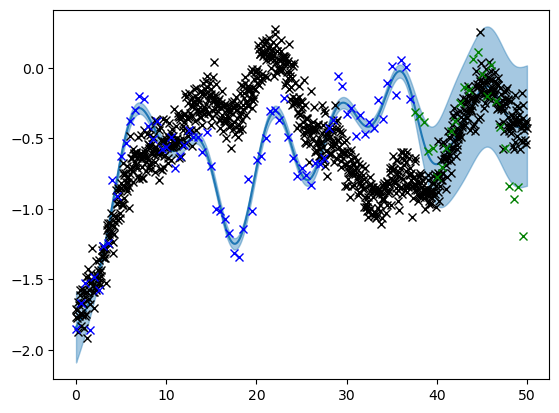

╒═════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════════╤═════════╤══════════════════╕
│ name                                    │ class     │ transform        │ prior   │ trainable   │ shape       │ dtype   │ value            │
╞═════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════════╪═════════╪══════════════════╡
│ SVGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()          │ float64 │ 1.0              │
├─────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────────┼─────────┼──────────────────┤
│ SVGP

2026-09-18 17:49:06.208157: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-18 17:49:06.416131: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

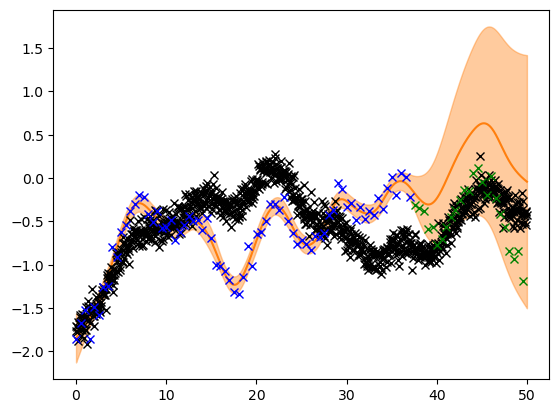

IVS 90 CMOGP 0.07183840605700481 SVGP 0.4377321199830104


In [ ]:
from atlikelihood import TransferLikelihood
from atmodel import SparseCMOGP
from robust_svgp import LMCInducingVariable

from atmodel import SparseCMOGP
from robust_svgp import LMCInducingVariable

def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50}, method="L-BFGS-B")
    plt.plot(res["loss_history"])
    plt.show()

for
Xs = np.linspace(0, 50, 1000).reshape(-1, 1)
Xt = np.linspace(0, 50, 1000).reshape(-1, 1)
f1 = np.random.multivariate_normal(np.zeros_like(Xs.flatten()), gpf.kernels.RBF(lengthscales=10, variance=2)(Xs))
f2 = np.random.multivariate_normal(np.zeros_like(Xt.flatten()), gpf.kernels.RBF(lengthscales=3)(Xt))

prop = 0.7
ys = (prop * f1 + (1-prop) * f2 + np.random.normal(0, 0.1, len(Xs))).reshape(-1, 1)
yt = ((1-prop)* f1 + prop * f2 + np.random.normal(0, 0.1, len(Xt))).reshape(-1, 1)
yt = [y for i, y in enumerate(yt) if i % 10 == 0]
Xt = [x for i, x in enumerate(Xt) if i % 10 == 0]
yt_train = yt[:int(len(Xt)*0.75)]
Xt_train = Xt[:int(len(Xt)*0.75)]
yt_test = yt[int(len(Xt)*0.75):]
Xt_test = Xt[int(len(Xt)*0.75):]


for nIVS in np.arange(10, 100, 10):
    output_dim = 2  # Number of outputs
    rank = 1  # Rank of W

    # Base kernel
    k = gpf.kernels.RBF()

    # Coregion kernel
    coreg = gpf.kernels.Coregion(
        output_dim=output_dim, rank=rank, active_dims=[1]
    )

    ivs = np.linspace(0, max(X[:,0]), nIVS).reshape(-1, 1)
    iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))
    shuffle = np.random.permutation(np.arange(len(ivs)))
    ivs = ivs[shuffle]
    ivs = np.hstack((ivs, iv_ind))

    kern = k * coreg 
    m = SparseCMOGP((X, y), jitter=10e-5, inducing_variable=LMCInducingVariable(ivs), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
    #gpf.set_trainable(m.kernel.kernels[0].variance, True)

    gpf.utilities.print_summary(m)
    optimize(m)
    gpf.utilities.print_summary(m)

    from sklearn.metrics import mean_squared_error
    Xall = Xs.reshape(-2, 1)
    Xplot = np.hstack((Xall, np.ones_like(Xall)))
    Xtst = np.hstack((Xt_test, np.ones_like(Xt_test)))
    fmean, fvar = m.predict_f(Xplot)
    fmean_tst, fvar_tst = m.predict_f(Xtst)
    plt.plot(Xall, fmean, color="C0")
    plt.plot(Xs, ys, "kx")
    plt.plot(Xt_train, yt_train, "bx")
    plt.plot(Xt_test, yt_test, "gx")
    plt.fill_between(
        Xall[:, -1],
        (fmean - 1 * np.sqrt(fvar))[:, 0],
        (fmean + 1 * np.sqrt(fvar))[:, 0],
        color="C0",
        alpha=0.4,
    )
    plt.show()

    cmogp_mse = mean_squared_error(yt_test, fmean_tst)

    from robust_svgp import LMCInducingPointsBase
    output_dim = 2  # Number of outputs
    rank = 1  # Rank of W

    # Base kernel
    k = gpf.kernels.Matern32()

    # Coregion kernel
    coreg = gpf.kernels.Coregion(
        output_dim=output_dim, rank=rank, active_dims=[1]
    )

    kern = k * coreg

    lik = TransferLikelihood(
        source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()
    )

    ivs = np.linspace(0, max(X[:,0]), nIVS).reshape(-1, 1)
    iv_ind = np.concatenate((np.ones((int(nIVS/2),1 )), np.zeros((int(nIVS/2), 1))))
    shuffle = np.random.permutation(np.arange(len(ivs)))
    ivs = ivs[shuffle]
    ivs = np.hstack((ivs, iv_ind))
    
    # now build the GP model as normal

    m = gpf.models.SVGP(kernel=kern, inducing_variable=LMCInducingPointsBase(ivs), num_data=len(X), likelihood=lik)
    gpf.utilities.print_summary(m)
    # fit the covariance function parameters
    gpf.optimizers.Scipy().minimize(
        m.training_loss_closure((X, y)), 
        m.trainable_variables,
        method="L-BFGS-B",
    )

    Xall = Xs.reshape(-1, 1)
    Xplot = np.hstack((Xall, np.ones_like(Xall)))
    Xtst = np.hstack((Xt_test, np.ones_like(Xt_test)))
    fmean, fvar = m.predict_f(Xplot)
    fmean_tst, fvar_tst = m.predict_f(Xtst)


    Xall = Xs.reshape(-1, 1)
    Xplot = np.hstack((Xall, np.ones_like(Xall)))
    Xtst = np.hstack((Xt_test, np.ones_like(Xt_test)))
    fmean, fvar = m.predict_f(Xplot)
    fmean_tst, fvar_tst = m.predict_f(Xtst)
    plt.plot(Xall, fmean, color="C1")
    plt.plot(Xs, ys, "kx")
    plt.plot(Xt_train, yt_train, "bx")
    plt.plot(Xt_test, yt_test, "gx")
    plt.fill_between(
        Xall[:, 0],
        (fmean - 2 * np.sqrt(fvar))[:, 0],
        (fmean + 2 * np.sqrt(fvar))[:, 0],
        color="C1",
        alpha=0.4,
    )
    plt.show()


    svgp_mse = mean_squared_error(yt_test, fmean_tst)
    print("IVS", nIVS, "CMOGP", cmogp_mse, "SVGP", svgp_mse)